# DFT 描述符与过渡态计算的耗时成本分析

**目标。** 用 9,237 个最终 IRC 验证过渡态及其对应组分的 Gaussian 日志，回答审稿人关于 DFT 级描述符代价的三个问题：

1. 在逐反应重复计入组分时，四类反应物/产物（LB–B、C–Cl、LB–B–Cl、碳自由基）的优化+单点耗时占总耗时的比例；
2. 对 9,237 条反应的组分去重后，该比例是多少；
3. 用实测 TS 平均耗时外推完整反应空间（20,010 × 179），比较只计算唯一反应物/产物与计算全空间（反应物+产物+TS）的成本。

本 notebook 生成逐日志缓存、逐物种表、逐反应表、汇总表和一张审稿用图。所有累计时间均为 Gaussian `Elapsed time` 的求和，即 **wall-time equivalent**，不是 CPU-hours，也不代表充分并行后的日历时间。

In [1]:
from __future__ import annotations

import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 从仓库根目录或 notebook 所在目录启动均可。
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "Data").exists():
    candidates = [p for p in [REPO_ROOT, *REPO_ROOT.parents] if (p / "Data").exists()]
    if not candidates:
        raise FileNotFoundError("无法定位包含 Data/ 的仓库根目录。")
    REPO_ROOT = candidates[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RAW_ROOT = Path(os.environ.get("BORYLXAT_RAW_CALC_ROOT", r"E:\work\B_Cl_Nu")).expanduser()
OUT_DIR = REPO_ROOT / "output" / "jupyter-notebook"
FIG_DIR = REPO_ROOT / "Figure"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

REQUIRE_COMPLETE = True
CACHE_EVERY = 2_000

print("REPO_ROOT =", REPO_ROOT)
print("RAW_ROOT  =", RAW_ROOT, "exists =", RAW_ROOT.exists())

REPO_ROOT = D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database
RAW_ROOT  = E:\work\B_Cl_Nu exists = True


## 1. 数据与计算口径

路径和文件命名严格沿用 `3_Build_DataBase.ipynb`：

- TS 优化：`Sum/TS_needIRC/`；TS 单点：`Sum/TS_ENG/`；
- 组分优化：`Data/GS_OPT/`；组分单点：`Data/GS_SPE/`；
- LB–B 与 LB–B–Cl 分别对应 `B_N_r` / `B_N_p`；C–Cl 与碳自由基分别对应 `Cl_r` / `Cl_p`；
- 对重复 Lewis-base 反应位点，使用 `B_N_*_d` 和带 `Naid` 的文件名；
- 每个物种只读取 CSV 中记录的最终选中构象编号。

这里的 **TS 成本 = 最终 TS 优化/频率 + TS SPE**。不包括限制优化、IRC、失败任务/重算、xTB/CREST 和描述符提取后处理；这些属于完整生产流水线，而不是本次要比较的 DFT 描述符边际成本。

In [2]:
bn = pd.read_csv(REPO_ROOT / "Data/csvs/reactants_B_N.csv")
cl = pd.read_csv(REPO_ROOT / "Data/csvs/reactants_Cl.csv").rename(columns={"Index": "Cl_Index"})
ts = pd.read_csv(REPO_ROOT / "Data/TS/Borane_all.csv")

# 与 1_Calc_Reactant.ipynb / 3_Build_DataBase.ipynb 一致。
DUPLICATE_N_IDS = {
    9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352,
    353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376,
}

screen_cl = cl.loc[pd.to_numeric(cl["Experiment"], errors="coerce").fillna(0).eq(0)].copy()

checks = pd.Series({
    "TS rows": len(ts),
    "unique TS triples": ts[["B_Index", "N_Index", "Cl_Index"]].drop_duplicates().shape[0],
    "retained LB-B": len(bn),
    "screening C-Cl (Experiment=0)": len(screen_cl),
    "full reaction space": len(bn) * len(screen_cl),
}, name="count")
display(checks.to_frame())

assert len(ts) == 9_237
assert len(bn) == 20_010
assert len(screen_cl) == 179
assert len(bn) * len(screen_cl) == 3_581_790

,count
TS rows,9237
unique TS triples,9237
retained LB-B,20010
screening C-Cl (Experiment=0),179
full reaction space,3581790


### 与项目现有耗时读取方法保持一致

`DFTStructureGenerator/logfile_process.py::Logfile.read_log_time()` 会遍历日志中所有 `Elapsed time:` 行，将 day/hour/minute/second 换算成分钟后求和。下面的批量读取器复现同一公式，但只扫描这些行，避免完整构造 `Logfile` 时同时解析坐标、频率和能量。随后用项目类的方法抽样核对数值。

In [3]:
ELAPSED_RE = re.compile(
    r"Elapsed time:\s*([0-9.]+)\s+days?\s*([0-9.]+)\s+hours?\s*"
    r"([0-9.]+)\s+minutes?\s*([0-9.]+)\s+seconds?",
    flags=re.IGNORECASE,
)

def elapsed_minutes_fast(path: Path) -> float:
    # 与 Logfile.read_log_time 相同口径，只读取 Elapsed time 行。
    total = 0.0
    hits = 0
    with path.open("rt", errors="ignore") as handle:
        for line in handle:
            if "Elapsed time:" not in line:
                continue
            match = ELAPSED_RE.search(line)
            if match is None:
                raise ValueError(f"无法解析 Elapsed time 行: {path}\n{line.rstrip()}")
            days, hours, minutes, seconds = map(float, match.groups())
            total += days * 24 * 60 + hours * 60 + minutes + seconds / 60
            hits += 1
    if hits == 0:
        raise ValueError(f"日志中没有 Elapsed time: {path}")
    return total

def project_elapsed_minutes(path: Path) -> float:
    # 直接调用项目 Logfile.read_log_time，用于抽样一致性核对。
    from DFTStructureGenerator.logfile_process import Logfile

    reader = object.__new__(Logfile)
    with path.open("rt", errors="ignore") as handle:
        reader.filelines = handle.readlines()
    return float(Logfile.read_log_time(reader))

def write_cache(records: dict[str, dict], path: Path) -> None:
    pd.DataFrame(records.values()).sort_values("path").to_csv(path, index=False)

def resolve_log_times(paths: list[Path], cache_path: Path) -> pd.DataFrame:
    # 按路径、文件大小和 mtime 复用缓存；中途定期落盘，便于断点续跑。
    paths = list(dict.fromkeys(Path(p) for p in paths))
    cached: dict[str, dict] = {}
    if cache_path.exists():
        old = pd.read_csv(cache_path)
        cached = {str(row["path"]): row.to_dict() for _, row in old.iterrows()}

    for i, path in enumerate(paths, start=1):
        key = str(path)
        if not path.exists():
            record = {"path": key, "size": np.nan, "mtime_ns": np.nan,
                      "elapsed_min": np.nan, "status": "missing"}
        else:
            stat = path.stat()
            prior = cached.get(key)
            reusable = (
                prior is not None
                and prior.get("status") == "ok"
                and int(prior.get("size", -1)) == stat.st_size
                and int(prior.get("mtime_ns", -1)) == stat.st_mtime_ns
            )
            if reusable:
                continue
            try:
                value = elapsed_minutes_fast(path)
                record = {"path": key, "size": stat.st_size, "mtime_ns": stat.st_mtime_ns,
                          "elapsed_min": value, "status": "ok"}
            except Exception as exc:
                record = {"path": key, "size": stat.st_size, "mtime_ns": stat.st_mtime_ns,
                          "elapsed_min": np.nan, "status": f"parse_error: {exc}"}
        cached[key] = record
        if i % CACHE_EVERY == 0:
            write_cache(cached, cache_path)
            print(f"scanned {i:,}/{len(paths):,} unique logs")

    write_cache(cached, cache_path)
    return pd.DataFrame(cached.values())

In [4]:
def bn_log_paths(row: pd.Series, state: str) -> tuple[Path, Path]:
    b_id, n_id, n_atom = int(row.B_Index), int(row.N_Index), int(row.N_Atomid)
    conf = int(row[f"conf_idxs_{state}"])
    if n_id in DUPLICATE_N_IDS:
        subdir = f"B_N_{state}_d"
        stem = f"B_{b_id:05}_Nu_{n_id:05}_Naid_{n_atom:05}_{state}_{conf:04}"
    else:
        subdir = f"B_N_{state}"
        stem = f"B_{b_id:05}_Nu_{n_id:05}_{state}_{conf:04}"
    opt = RAW_ROOT / "Data" / "GS_OPT" / subdir / f"{stem}.log"
    spe = RAW_ROOT / "Data" / "GS_SPE" / subdir / f"{stem}.log"
    return opt, spe

def cl_log_paths(row: pd.Series, state: str) -> tuple[Path, Path]:
    cl_id = int(row.Cl_Index)
    conf = int(row[f"conf_idxs_{state}"])
    stem = f"Cl_{cl_id:05}_{state}_{conf:04}"
    opt = RAW_ROOT / "Data" / "GS_OPT" / f"Cl_{state}" / f"{stem}.log"
    spe = RAW_ROOT / "Data" / "GS_SPE" / f"Cl_{state}" / f"{stem}.log"
    return opt, spe

def ts_log_paths(row: pd.Series) -> tuple[Path, Path]:
    b_id, n_id, cl_id = int(row.B_Index), int(row.N_Index), int(row.Cl_Index)
    conf = int(row.conf_idxs_ts)
    stem = f"B_{b_id:05}_Nu_{n_id:05}_Cl_{cl_id:05}"
    candidates = [
        RAW_ROOT / "Sum" / "TS_needIRC" / f"{stem}.log",
        RAW_ROOT / "Sum" / "TS_needIRC" / f"{stem}_{conf:04}.log",
    ]
    opt = next((path for path in candidates if path.exists()), candidates[-1])
    spe = RAW_ROOT / "Sum" / "TS_ENG" / opt.name
    return opt, spe

species_records = []
for _, row in bn.iterrows():
    b_id, n_id, n_atom = int(row.B_Index), int(row.N_Index), int(row.N_Atomid)
    entity_key = f"BN:{b_id}:{n_id}:{n_atom}"
    for state, label in [("r", "LB-B"), ("p", "LB-B-Cl")]:
        opt, spe = bn_log_paths(row, state)
        species_records.append({
            "entity_key": entity_key, "species_id": f"{entity_key}:{state}",
            "family": "BN", "state": state, "label": label,
            "B_Index": b_id, "N_Index": n_id, "N_Atomid": n_atom,
            "Cl_Index": np.nan, "opt_path": str(opt), "spe_path": str(spe),
        })

for _, row in cl.iterrows():
    cl_id = int(row.Cl_Index)
    entity_key = f"Cl:{cl_id}"
    for state, label in [("r", "C-Cl"), ("p", "C radical")]:
        opt, spe = cl_log_paths(row, state)
        species_records.append({
            "entity_key": entity_key, "species_id": f"{entity_key}:{state}",
            "family": "Cl", "state": state, "label": label,
            "B_Index": np.nan, "N_Index": np.nan, "N_Atomid": np.nan,
            "Cl_Index": cl_id, "opt_path": str(opt), "spe_path": str(spe),
        })

species_manifest = pd.DataFrame(species_records)

ts_records = []
for _, row in ts.iterrows():
    opt, spe = ts_log_paths(row)
    ts_records.append({
        "reaction_key": f"TS:{int(row.B_Index)}:{int(row.N_Index)}:{int(row.Cl_Index)}",
        "B_Index": int(row.B_Index), "N_Index": int(row.N_Index),
        "N_Atomid": int(row.N_Atomid), "Cl_Index": int(row.Cl_Index),
        "opt_path": str(opt), "spe_path": str(spe),
    })
ts_manifest = pd.DataFrame(ts_records)

all_paths = [Path(p) for p in pd.concat([
    species_manifest["opt_path"], species_manifest["spe_path"],
    ts_manifest["opt_path"], ts_manifest["spe_path"],
], ignore_index=True)]
print(f"species = {len(species_manifest):,}; TS = {len(ts_manifest):,}; unique logs = {len(set(all_paths)):,}")

species = 40,382; TS = 9,237; unique logs = 99,238


In [5]:
cache_path = OUT_DIR / "runtime_cost_log_cache.csv"
log_times = resolve_log_times(all_paths, cache_path)
time_map = log_times.set_index("path")["elapsed_min"]

bad = log_times.loc[log_times["status"].ne("ok") & log_times["path"].isin({str(p) for p in all_paths})]
coverage = pd.Series({
    "required unique logs": len(set(all_paths)),
    "parsed OK": len(set(all_paths)) - len(bad),
    "missing/parse errors": len(bad),
    "coverage (%)": 100 * (len(set(all_paths)) - len(bad)) / len(set(all_paths)),
}, name="value")
display(coverage.to_frame())
if len(bad):
    display(bad.head(20))
    if REQUIRE_COMPLETE:
        raise RuntimeError("耗时日志覆盖不完整；见上表和 runtime_cost_log_cache.csv。")

# 快速读取器与项目原方法的抽样一致性核对。
samples = [Path(p) for p in [
    species_manifest.iloc[0].opt_path,
    species_manifest.loc[species_manifest.label.eq("C-Cl")].iloc[0].opt_path,
    ts_manifest.iloc[0].opt_path,
]]
crosscheck = pd.DataFrame({
    "path": [str(p) for p in samples],
    "fast_min": [elapsed_minutes_fast(p) for p in samples],
    "Logfile.read_log_time_min": [project_elapsed_minutes(p) for p in samples],
})
crosscheck["abs_delta_min"] = (crosscheck.fast_min - crosscheck["Logfile.read_log_time_min"]).abs()
display(crosscheck)
assert crosscheck.abs_delta_min.max() < 1e-10

,value
required unique logs,"99,238.0000"
parsed OK,"99,238.0000"
missing/parse errors,0.0000
coverage (%),100.0000


,path,fast_min,Logfile.read_log_time_min,abs_delta_min
0,E:\work\B_Cl_Nu\Data\GS_OPT\B_N_r\B_00388_Nu_0...,3.5300,3.5300,0.0000
1,E:\work\B_Cl_Nu\Data\GS_OPT\Cl_r\Cl_00443_r_00...,1.3800,1.3800,0.0000
2,E:\work\B_Cl_Nu\Sum\TS_needIRC\B_00388_Nu_0000...,17.1133,17.1133,0.0000


In [6]:
species_times = species_manifest.copy()
species_times["opt_min"] = species_times["opt_path"].map(time_map)
species_times["spe_min"] = species_times["spe_path"].map(time_map)
species_times["opt_spe_min"] = species_times["opt_min"] + species_times["spe_min"]

ts_times = ts_manifest.copy()
ts_times["ts_opt_min"] = ts_times["opt_path"].map(time_map)
ts_times["ts_spe_min"] = ts_times["spe_path"].map(time_map)
ts_times["ts_opt_spe_min"] = ts_times["ts_opt_min"] + ts_times["ts_spe_min"]

assert species_times[["opt_min", "spe_min"]].notna().all().all()
assert ts_times[["ts_opt_min", "ts_spe_min"]].notna().all().all()

species_times.to_csv(OUT_DIR / "runtime_cost_species.csv", index=False)
display(species_times.groupby("label")[["opt_min", "spe_min", "opt_spe_min"]].agg(["count", "mean", "median"]))

opt_min                 spe_min               opt_spe_min          \
            count    mean  median   count   mean median       count    mean   
label                                                                         
C radical     181  3.0857  2.2683     181 0.4093 0.3367         181  3.4950   
C-Cl          181  1.9133  1.5483     181 0.3531 0.3033         181  2.2664   
LB-B        20010 21.0968 11.0350   20010 3.2213 2.1583       20010 24.3181   
LB-B-Cl     20010 12.7575  8.1683   20010 1.6559 1.1700       20010 14.4134   

                   
           median  
label              
C radical  2.6883  
C-Cl       1.9100  
LB-B      13.5492  
LB-B-Cl    9.4200

## 2. 问题 1：9,237 条反应逐条计入，允许组分重复

每条反应都重新计入其四个组分的优化+SPE，正好对应“重复的反应物和产物优化也算上”。同时报告两种容易混淆但都合理的比例：

- **逐反应比例的平均值**：先对每条反应求比例，再取平均（主回答）；
- **总和之比**：所有重复计入的组分耗时总和 / 所有重复计入的完整耗时总和（耗时加权结果）。

In [7]:
bn_runtime = species_times.loc[species_times.family.eq("BN")].set_index(
    ["B_Index", "N_Index", "state"]
)["opt_spe_min"].to_dict()
bn_opt = species_times.loc[species_times.family.eq("BN")].set_index(
    ["B_Index", "N_Index", "state"]
)["opt_min"].to_dict()
bn_spe = species_times.loc[species_times.family.eq("BN")].set_index(
    ["B_Index", "N_Index", "state"]
)["spe_min"].to_dict()
cl_runtime = species_times.loc[species_times.family.eq("Cl")].set_index(
    ["Cl_Index", "state"]
)["opt_spe_min"].to_dict()
cl_opt = species_times.loc[species_times.family.eq("Cl")].set_index(
    ["Cl_Index", "state"]
)["opt_min"].to_dict()
cl_spe = species_times.loc[species_times.family.eq("Cl")].set_index(
    ["Cl_Index", "state"]
)["spe_min"].to_dict()

reaction_times = ts_times.copy()
reaction_times["LB_B_opt_min"] = [bn_opt[(b, n, "r")] for b, n in zip(reaction_times.B_Index, reaction_times.N_Index)]
reaction_times["LB_B_spe_min"] = [bn_spe[(b, n, "r")] for b, n in zip(reaction_times.B_Index, reaction_times.N_Index)]
reaction_times["LB_B_min"] = reaction_times.LB_B_opt_min + reaction_times.LB_B_spe_min
reaction_times["C_Cl_opt_min"] = [cl_opt[(c, "r")] for c in reaction_times.Cl_Index]
reaction_times["C_Cl_spe_min"] = [cl_spe[(c, "r")] for c in reaction_times.Cl_Index]
reaction_times["C_Cl_min"] = reaction_times.C_Cl_opt_min + reaction_times.C_Cl_spe_min
reaction_times["LB_B_Cl_opt_min"] = [bn_opt[(b, n, "p")] for b, n in zip(reaction_times.B_Index, reaction_times.N_Index)]
reaction_times["LB_B_Cl_spe_min"] = [bn_spe[(b, n, "p")] for b, n in zip(reaction_times.B_Index, reaction_times.N_Index)]
reaction_times["LB_B_Cl_min"] = reaction_times.LB_B_Cl_opt_min + reaction_times.LB_B_Cl_spe_min
reaction_times["C_radical_opt_min"] = [cl_opt[(c, "p")] for c in reaction_times.Cl_Index]
reaction_times["C_radical_spe_min"] = [cl_spe[(c, "p")] for c in reaction_times.Cl_Index]
reaction_times["C_radical_min"] = reaction_times.C_radical_opt_min + reaction_times.C_radical_spe_min

component_cols = ["LB_B_min", "C_Cl_min", "LB_B_Cl_min", "C_radical_min"]
reaction_times["components_min"] = reaction_times[component_cols].sum(axis=1)
reaction_times["complete_min"] = reaction_times.components_min + reaction_times.ts_opt_spe_min
reaction_times["component_fraction"] = reaction_times.components_min / reaction_times.complete_min

assert len(reaction_times) == 9_237
assert reaction_times[[*component_cols, "ts_opt_spe_min", "component_fraction"]].notna().all().all()
reaction_times.to_csv(OUT_DIR / "runtime_cost_reaction_9237.csv", index=False)

task1_distribution = pd.DataFrame({
    "LB-B": reaction_times.LB_B_min,
    "C-Cl": reaction_times.C_Cl_min,
    "LB-B-Cl": reaction_times.LB_B_Cl_min,
    "C radical": reaction_times.C_radical_min,
    "TS": reaction_times.ts_opt_spe_min,
}).agg(["count", "mean", "median", "std", "min", lambda s: s.quantile(.25), lambda s: s.quantile(.75), "max"]).T
task1_distribution.columns = ["count", "mean_min", "median_min", "std_min", "min_min", "q25_min", "q75_min", "max_min"]
display(task1_distribution)

task1_metrics = pd.Series({
    "mean per-reaction component fraction": reaction_times.component_fraction.mean(),
    "median per-reaction component fraction": reaction_times.component_fraction.median(),
    "ratio of duplicated component sums": reaction_times.components_min.sum() / reaction_times.complete_min.sum(),
    "duplicated component total (h)": reaction_times.components_min.sum() / 60,
    "TS total (h)": reaction_times.ts_opt_spe_min.sum() / 60,
    "duplicated complete total (h)": reaction_times.complete_min.sum() / 60,
}, name="value")
display(task1_metrics.to_frame())

,count,mean_min,median_min,std_min,min_min,q25_min,q75_min,max_min
LB-B,"9,237.0000",20.2243,11.6800,27.7866,0.6767,6.7900,25.2833,397.7867
C-Cl,"9,237.0000",2.0457,1.7683,1.4374,0.3283,1.2000,2.5617,10.1217
LB-B-Cl,"9,237.0000",10.8968,7.8667,11.3058,0.9283,5.0683,12.6433,185.9900
C radical,"9,237.0000",3.2670,2.5033,2.5633,0.4517,1.6017,4.1750,16.6417
TS,"9,237.0000",48.6242,38.4100,39.1498,2.4133,24.0467,60.4650,633.7767


,value
mean per-reaction component fraction,0.4307
median per-reaction component fraction,0.4288
ratio of duplicated component sums,0.4283
duplicated component total (h),"5,608.9890"
TS total (h),"7,485.6933"
duplicated complete total (h),"13,094.6824"


## 3. 问题 2：对 9,237 条反应使用到的组分去重

去重单位是实际 DFT 物种：每个唯一 LB–B 组合需要 `r` 与 `p` 两个物种，每个唯一氯底物需要 C–Cl (`r`) 与碳自由基 (`p`) 两个物种。TS 仍为 9,237 个，不去重。

In [8]:
used_bn = set(zip(reaction_times.B_Index.astype(int), reaction_times.N_Index.astype(int)))
used_cl = set(reaction_times.Cl_Index.astype(int))
bn_mask = species_times.family.eq("BN")
cl_mask = species_times.family.eq("Cl")
used_mask = pd.Series(False, index=species_times.index)
used_mask.loc[bn_mask] = [
    (int(b), int(n)) in used_bn
    for b, n in zip(species_times.loc[bn_mask, "B_Index"], species_times.loc[bn_mask, "N_Index"])
]
used_mask.loc[cl_mask] = species_times.loc[cl_mask, "Cl_Index"].isin(used_cl)
used_species = species_times.loc[used_mask].copy()

task2_component_min = used_species.opt_spe_min.sum()
task2_ts_min = reaction_times.ts_opt_spe_min.sum()
task2_complete_min = task2_component_min + task2_ts_min
task2_ratio = task2_component_min / task2_complete_min

task2_metrics = pd.Series({
    "unique LB-B combinations": len(used_bn),
    "unique C-Cl substrates": len(used_cl),
    "unique DFT component species (r+p)": len(used_species),
    "unique component total (h)": task2_component_min / 60,
    "9,237 TS total (h)": task2_ts_min / 60,
    "unique component + TS total (h)": task2_complete_min / 60,
    "unique component fraction": task2_ratio,
}, name="value")
display(task2_metrics.to_frame())

,value
unique LB-B combinations,"4,363.0000"
unique C-Cl substrates,178.0000
unique DFT component species (r+p),"9,082.0000"
unique component total (h),"2,329.2371"
"9,237 TS total (h)","7,485.6933"
unique component + TS total (h),"9,814.9304"
unique component fraction,0.2373


## 4. 问题 3：外推完整 20,010 × 179 反应空间

- 完整空间 TS 成本：`9,237 个 TS 的平均(优化+SPE) × 3,581,790`；
- 描述符组分成本：20,010 个 LB–B 组合各算 `r/p` 一次，加 179 个非实验扩展氯底物各算 `r/p` 一次；
- 分母：上述唯一组分成本 + 全空间投影 TS 成本。

该外推假定未计算空间中的 TS 平均 wall time 与已完成的 9,237 个相同。由于分子大小/化学类型分布可能不同，结果应称为 **经验外推**，而非精确排队时间预测。

In [9]:
screen_cl_ids = set(screen_cl.Cl_Index.astype(int))
full_species = species_times.loc[
    species_times.family.eq("BN")
    | (species_times.family.eq("Cl") & species_times.Cl_Index.isin(screen_cl_ids))
].copy()

full_reaction_count = len(bn) * len(screen_cl)
mean_ts_min = reaction_times.ts_opt_spe_min.mean()
projected_ts_min = mean_ts_min * full_reaction_count
full_component_min = full_species.opt_spe_min.sum()
projected_complete_min = full_component_min + projected_ts_min
task3_ratio = full_component_min / projected_complete_min

task3_metrics = pd.Series({
    "full reaction count": full_reaction_count,
    "mean TS opt+SPE (h/TS)": mean_ts_min / 60,
    "full unique DFT component species": len(full_species),
    "full unique component total (h)": full_component_min / 60,
    "projected full-space TS total (h)": projected_ts_min / 60,
    "projected complete total (h)": projected_complete_min / 60,
    "full-space component fraction": task3_ratio,
    "TS-to-component speedup factor": projected_ts_min / full_component_min,
}, name="value")
display(task3_metrics.to_frame())

,value
full reaction count,"3,581,790.0000"
mean TS opt+SPE (h/TS),0.8104
full unique DFT component species,"40,378.0000"
full unique component total (h),"12,934.0111"
projected full-space TS total (h),"2,902,693.6802"
projected complete total (h),"2,915,627.6913"
full-space component fraction,0.0044
TS-to-component speedup factor,224.4233


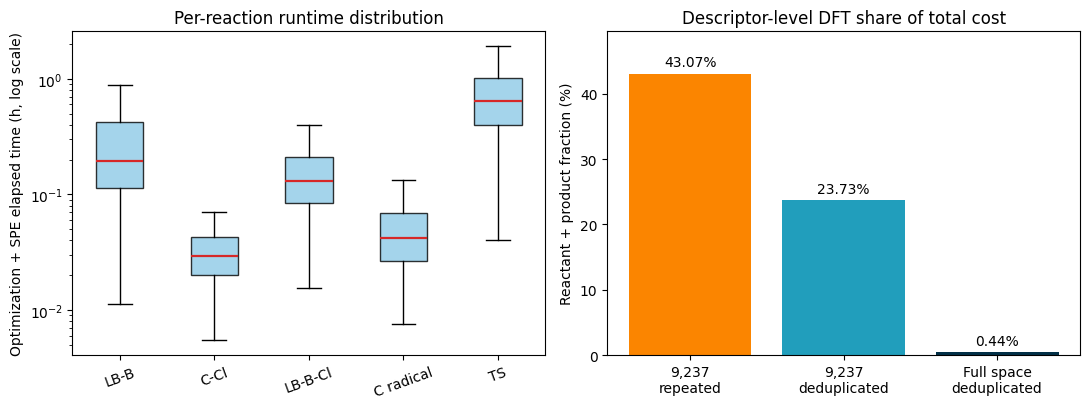

saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\FigureS_DFT_descriptor_runtime_cost.png


In [10]:
labels = ["LB-B", "C-Cl", "LB-B-Cl", "C radical", "TS"]
values = [
    reaction_times.LB_B_min / 60,
    reaction_times.C_Cl_min / 60,
    reaction_times.LB_B_Cl_min / 60,
    reaction_times.C_radical_min / 60,
    reaction_times.ts_opt_spe_min / 60,
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].boxplot(values, tick_labels=labels, showfliers=False, patch_artist=True,
                boxprops={"facecolor": "#8ecae6", "alpha": 0.8},
                medianprops={"color": "#d62828", "linewidth": 1.6})
axes[0].set_yscale("log")
axes[0].set_ylabel("Optimization + SPE elapsed time (h, log scale)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_title("Per-reaction runtime distribution")

ratio_labels = ["9,237\nrepeated", "9,237\ndeduplicated", "Full space\ndeduplicated"]
ratios = [
    reaction_times.component_fraction.mean(),
    task2_ratio,
    task3_ratio,
]
bars = axes[1].bar(ratio_labels, np.array(ratios) * 100, color=["#fb8500", "#219ebc", "#023047"])
axes[1].set_ylabel("Reactant + product fraction (%)")
axes[1].set_ylim(0, max(ratios) * 115)
axes[1].set_title("Descriptor-level DFT share of total cost")
axes[1].bar_label(bars, labels=[f"{r:.2%}" for r in ratios], padding=3)

fig.tight_layout()
figure_path = FIG_DIR / "FigureS_DFT_descriptor_runtime_cost.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()
print("saved:", figure_path)

In [11]:
summary_rows = [
    {"question": 1, "metric": "mean_per_reaction_component_fraction", "value": reaction_times.component_fraction.mean(), "unit": "fraction"},
    {"question": 1, "metric": "ratio_of_duplicated_component_sums", "value": reaction_times.components_min.sum() / reaction_times.complete_min.sum(), "unit": "fraction"},
    {"question": 1, "metric": "mean_TS_opt_SPE", "value": mean_ts_min / 60, "unit": "h_per_TS"},
    {"question": 2, "metric": "deduplicated_component_fraction_9237", "value": task2_ratio, "unit": "fraction"},
    {"question": 2, "metric": "deduplicated_component_total", "value": task2_component_min / 60, "unit": "wall_h_equivalent"},
    {"question": 3, "metric": "full_reaction_count", "value": full_reaction_count, "unit": "reactions"},
    {"question": 3, "metric": "full_unique_component_fraction", "value": task3_ratio, "unit": "fraction"},
    {"question": 3, "metric": "full_unique_component_total", "value": full_component_min / 60, "unit": "wall_h_equivalent"},
    {"question": 3, "metric": "projected_full_space_TS_total", "value": projected_ts_min / 60, "unit": "wall_h_equivalent"},
    {"question": 3, "metric": "projected_TS_to_component_factor", "value": projected_ts_min / full_component_min, "unit": "fold"},
]
summary = pd.DataFrame(summary_rows)
summary_path = REPO_ROOT / "Data/csvs/runtime_cost_summary.csv"
summary.to_csv(summary_path, index=False)
task1_distribution.to_csv(OUT_DIR / "runtime_cost_distribution_9237.csv")

display(summary)
print("saved:", summary_path)
print("saved:", OUT_DIR / "runtime_cost_species.csv")
print("saved:", OUT_DIR / "runtime_cost_reaction_9237.csv")
print("saved:", OUT_DIR / "runtime_cost_distribution_9237.csv")
print("saved:", cache_path)

,question,metric,value,unit
0,1,mean_per_reaction_component_fraction,0.4307,fraction
1,1,ratio_of_duplicated_component_sums,0.4283,fraction
2,1,mean_TS_opt_SPE,0.8104,h_per_TS
3,2,deduplicated_component_fraction_9237,0.2373,fraction
4,2,deduplicated_component_total,"2,329.2371",wall_h_equivalent
5,3,full_reaction_count,"3,581,790.0000",reactions
6,3,full_unique_component_fraction,0.0044,fraction
7,3,full_unique_component_total,"12,934.0111",wall_h_equivalent
8,3,projected_full_space_TS_total,"2,902,693.6802",wall_h_equivalent
9,3,projected_TS_to_component_factor,224.4233,fold


saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\csvs\runtime_cost_summary.csv
saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\runtime_cost_species.csv
saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\runtime_cost_reaction_9237.csv
saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\runtime_cost_distribution_9237.csv
saved: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\output\jupyter-notebook\runtime_cost_log_cache.csv


In [12]:
print("审稿回复可直接使用的结果（wall-time equivalent）：")
print(f"1) 逐反应重复计入：四类组分占完整(组分+TS)耗时的平均比例 = {reaction_times.component_fraction.mean():.2%}；")
print(f"   以总耗时加权的总和之比 = {reaction_times.components_min.sum() / reaction_times.complete_min.sum():.2%}。")
print(f"2) 9,237 条反应组分去重：{len(used_species):,} 个唯一 DFT 物种，占比 = {task2_ratio:.2%}。")
print(f"3) 平均每个 TS 优化+SPE = {mean_ts_min/60:.2f} h；完整空间 = {full_reaction_count:,} 条。")
print(f"   只计算 {len(full_species):,} 个唯一组分占投影完整成本 = {task3_ratio:.3%}，")
print(f"   即投影 TS 成本约为唯一组分成本的 {projected_ts_min/full_component_min:,.1f} 倍。")

审稿回复可直接使用的结果（wall-time equivalent）：
1) 逐反应重复计入：四类组分占完整(组分+TS)耗时的平均比例 = 43.07%；
   以总耗时加权的总和之比 = 42.83%。
2) 9,237 条反应组分去重：9,082 个唯一 DFT 物种，占比 = 23.73%。
3) 平均每个 TS 优化+SPE = 0.81 h；完整空间 = 3,581,790 条。
   只计算 40,378 个唯一组分占投影完整成本 = 0.444%，
   即投影 TS 成本约为唯一组分成本的 224.4 倍。


## 5. 解释边界与下一步

- 这里回答的是“获得 DFT 级描述符所需的最终优化+SPE”相对于“再计算 TS 优化+SPE”的代价；没有把限制优化、IRC 和失败重算算进 TS，因此对完整 TS 生产成本而言是保守估计。
- `Elapsed time` 是 wall time。若不同任务使用的核数不一致，不应把累计小时直接称为 CPU-hours；比例仍适合说明实际计算资源量级，但正式文字应保留 *wall-time equivalent*。
- 完整空间投影使用已成功 TS 的平均耗时，可能受成功样本和分子大小分布偏差影响。若要给不确定区间，可按 LB 类型、Cl 类型或原子数分层 bootstrap；本次主问题不需要额外模型即可回答。
- 更强的审稿表述应强调：DFT 描述符方案仍需要组分量化计算，并非“零成本”，但组分可以跨数百万组合复用，因而在完整组合空间中摊薄得非常显著。